In [ ]:
#Preprocessing
#BERT For Amharic Medical Question Answering
#Dataset: AmhMedQA.csv and ICHI.csv
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from torch.optim import  AdamW
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
#Load Datase
AmhMedQA = pd.read_csv("/content/drive/MyDrive/PHD folder/QA dataset/AmhMedQA.csv")
AmQA=pd.read_csv("/content/drive/MyDrive/PHD folder/QA dataset/AmQA2628.csv")
AmQA.head()
AmhMedQA.head()
#Missing Values
print("="*60)
print("Missing Values")
print("="*60)

missing = AmhMedQA.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values,
    "Percentage": (missing.values/len(AmhMedQA))*100
})

#Duplicate Values
print("="*60)
print("Duplicate Records")
print("="*60)
print("Entire duplicate rows:", AmhMedQA.duplicated().sum())
print("Duplicate Questions:",
      AmhMedQA["Question"].duplicated().sum())
print("Duplicate Contexts:",
      AmhMedQA["context"].duplicated().sum())
print("Duplicate Answers:",
      AmhMedQA["Answer"].duplicated().sum())
display(missing_df)


Missing Values
Duplicate Records
Entire duplicate rows: 17
Duplicate Questions: 32
Duplicate Contexts: 167
Duplicate Answers: 56


,Column,Missing Values,Percentage
0,Question,0,0.000000
1,Answer,7,0.258684
2,context,9,0.332594
3,Unnamed: 3,2704,99.926090


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.4 MB/s eta 0:00:00


In [1]:
#BERT QA using 42 Seed using AmhMedQA dataset
!pip install -q transformers datasets evaluate accelerate sentencepiece --quiet
import pandas as pd
import numpy as np
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    TrainingArguments,
    Trainer,
    default_data_collator)
import evaluate
# Load dataset
df =  pd.read_csv("/content/drive/MyDrive/PHD folder/QA dataset/AmhMedQA.csv")
# Check missing values
print(df.isnull().sum())

# Convert all text columns to string
df["context"] = df["context"].fillna("").astype(str)
df["Question"] = df["Question"].fillna("").astype(str)
df["Answer"] = df["Answer"].fillna("").astype(str)

# Remove empty rows
df = df[
    (df["context"].str.len() > 0) &
    (df["Question"].str.len() > 0) &
    (df["Answer"].str.len() > 0)]
print(df.head())
print(df.dtypes)
#Convert into hugging Face Dataset
dataset = Dataset.from_pandas(df)
dataset = dataset.train_test_split(
    test_size=0.2,
    seed=42)
train_dataset = dataset["train"]
test_dataset = dataset["test"]
print(train_dataset)
print(test_dataset)
model_name = "rasyosef/bert-medium-amharic"
tokenizer = AutoTokenizer.from_pretrained(model_name)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForQuestionAnswering.from_pretrained(
    model_name, ignore_mismatched_sizes=True).to(device)
def preprocess_function(examples):
    questions = [
        q.strip()
        for q in examples["Question"]
    ]
    inputs = tokenizer(
        questions,
        examples["context"],
        max_length=384,
        truncation="only_second",
        padding="max_length",
        return_offsets_mapping=True    )
    start_positions=[]
    end_positions=[]
    for i, offsets in enumerate(inputs["offset_mapping"]):
        answer = examples["Answer"][i]
        context = examples["context"][i]
        start_char = context.find(answer)
        end_char = start_char + len(answer)
        sequence_ids = inputs.sequence_ids(i)
        context_start = 0
        while sequence_ids[context_start] != 1:
            context_start += 1
        context_end = len(sequence_ids)-1
        while sequence_ids[context_end] != 1:
            context_end -= 1
        if start_char < 0:
            start_positions.append(0)
            end_positions.append(0)
        else:
            token_start=context_start
            while (
                token_start <= context_end and
                offsets[token_start][0] <= start_char
            ):
                token_start +=1

            token_start -=1

            token_end=context_end

            while (
                token_end >= context_start and
                offsets[token_end][1] >= end_char
            ):
                token_end -=1
            token_end +=1
            start_positions.append(token_start)
            end_positions.append(token_end)
    inputs.pop("offset_mapping")
    inputs["start_positions"]=start_positions
    inputs["end_positions"]=end_positions
    return inputs
train_dataset = train_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=train_dataset.column_names)
test_dataset = test_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=test_dataset.column_names)
print(train_dataset)
#Trainnig Configuration
training_args = TrainingArguments(
    output_dir="./bert_amharic_medical_QA",
    eval_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    weight_decay=0.01,
    save_strategy="epoch",
    logging_steps=50,
    report_to="none"
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=default_data_collator)
trainer.train()
# ============================================================
# Prediction Function
# ============================================================
def predict_answer(question, context):
    inputs = tokenizer(
        question,
        context,
        return_tensors="pt",
        truncation=True,
        max_length=384
    )
    # Move inputs to the same device as the model
    inputs = {
        key: value.to(model.device)
        for key, value in inputs.items()    }
    with torch.no_grad():
        outputs = model(**inputs)
    start = torch.argmax(
        outputs.start_logits,
        dim=1
    ).item()
    end = torch.argmax(
        outputs.end_logits,
        dim=1
    ).item()
    # Avoid invalid answer span
    if end < start:
        end = start
    answer_tokens = inputs["input_ids"][0][start:end+1]
    answer = tokenizer.decode(
        answer_tokens,
        skip_special_tokens=True
    )
    return answer
# ============================================================
# Calculate EM and F1
# ============================================================
def normalize(text):
    return text.strip()
def compute_f1(pred, truth):
    pred_tokens = normalize(pred).split()
    truth_tokens = normalize(truth).split()
    common = set(pred_tokens) & set(truth_tokens)
    if len(common) == 0:
        return 0
    precision = len(common) / len(pred_tokens)
    recall = len(common) / len(truth_tokens)
    f1 = (
        2 * precision * recall /
        (precision + recall)
    )
    return f1
# ============================================================
# Evaluation
# ============================================================
EM = []
F1 = []
for example in dataset["test"]:
    prediction = predict_answer(
        example["Question"],
        example["context"]    )
    truth = example["Answer"]
    EM.append(
        int(normalize(prediction) == normalize(truth)))
    F1.append(
        compute_f1(
            prediction,
            truth))
# Final Scores
EM_score = np.mean(EM) * 100
F1_score = np.mean(F1) * 100
# ============================================================
# Results Table
# ============================================================
results = pd.DataFrame(
    { "Model": ["BERT"],"EM": [round(EM_score, 2)],"F1": [round(F1_score, 2)]
    })
results

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00
Question         0
Answer           7
context          9
Unnamed: 3    2704
dtype: int64
                                            Question  \
0                                      ኦቲዝም ምንድን ነው?   
1                                የኦቲዝም መንስኤ ምንድን ነው?   
3                    ኦቲዝም ያለባቸው ልጆች ባህርይ ምን አይነት ነው?   
4  ኦቲዝም ያለባቸው ልጆች በተግባቦት እና በማኅበራዊ ግንኙነታቸው ምን ይመስላሉ?   
5            ኦቲዝም ያለባቸው ሰዎች ራሳቸውን ችለው መኖር የሚችሉ ናቸውን?   

                                              Answer  \
0  ኦቲዝም የአእምሮ እድገት ላይ የሚያጋጥም ውስንነት ነው። የዓለም ጤና ድር...   
1  የኦቲዝም መንስኤ አካባቢያዊ እና የዘር ችግርን ጨምሮ በርካታ ምክንያቶች ...   
3                     የኦቲዝም ያለባቸው ልጆች ባህርይ የተለያየ ነው።   
4  የኦቲዝም ያለባቸው ልጆች ባህርይ የተለያየ ሲሆን፣ በጊዜ ሒደትም ባህርያቸ...   
5  አው። አንዳንድ ኦቲዝም ያለባቸው ሰዎች ራሳቸውን ችለው መኖር የሚችሉ ሲሆ...   

                                             context Unnamed: 3  
0  ኦቲዝም የአእምሮ እድገት ላይ የሚያጋጥም ውስንነት ነው። የዓለም ጤና ድር...        NaN  
1  ኦቲዝም የአእምሮ እድገት ላይ የሚያጋጥ

config.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.23k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/274k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/725k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

,Model,EM,F1
0,BERT,9.09,67.05


BERT-Medium-Amharic Medical QA
Five Random Seeds
Model : rasyosef/bert-medium-amharic
Device: cuda
Seeds : [13, 21, 42, 77, 123]

Original dataset shape:
(2706, 4)

Missing values:
Question         0
Answer           7
context          9
Unnamed: 3    2704
dtype: int64

Dataset after cleaning:
(2691, 4)

Valid examples: 2543
Invalid answer spans: 148

Hugging Face Dataset:
Dataset({
    features: ['Question', 'Answer', 'context', 'Unnamed: 3', 'answer_start'],
    num_rows: 2543
})

Tokenizer loaded successfully.



STARTING EXPERIMENT - SEED 13

Seed 13 training samples: 2034
Seed 13 testing samples: 509


Map:   0%|          | 0/2034 [00:00<?, ? examples/s]

Map:   0%|          | 0/509 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

[transformers] BertForQuestionAnswering LOAD REPORT from: rasyosef/bert-medium-amharic
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
qa_outputs.weight                          | MISSING    | 
qa_outputs.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

,Seed,EM (%),F1 (%)
0,13,11.00,69.63
1,21,9.23,70.12
2,42,9.63,69.54
3,77,10.81,69.83
4,123,10.22,69.22



OVERALL FIVE-SEED RESULTS
EM Mean ± Std: 10.18 ± 0.75
F1 Mean ± Std: 69.67 ± 0.34

PUBLICATION SUMMARY


,Model,EM Mean (%),EM Std (%),F1 Mean (%),F1 Std (%)
0,BERT-Medium-Amharic,10.18,0.75,69.67,0.34



TRAINING AND VALIDATION LOSS TABLE


,Seed,Epoch,Training Loss,Validation Loss
0,13,0.196078,3.759507,NaN
1,13,0.392157,1.294096,NaN
2,13,0.588235,0.505475,NaN
3,13,0.784314,0.443070,NaN
4,13,0.980392,0.401474,NaN
...,...,...,...,...
85,123,2.352941,0.343195,NaN
86,123,2.549020,0.350999,NaN
87,123,2.745098,0.244781,NaN
88,123,2.941176,0.318517,NaN


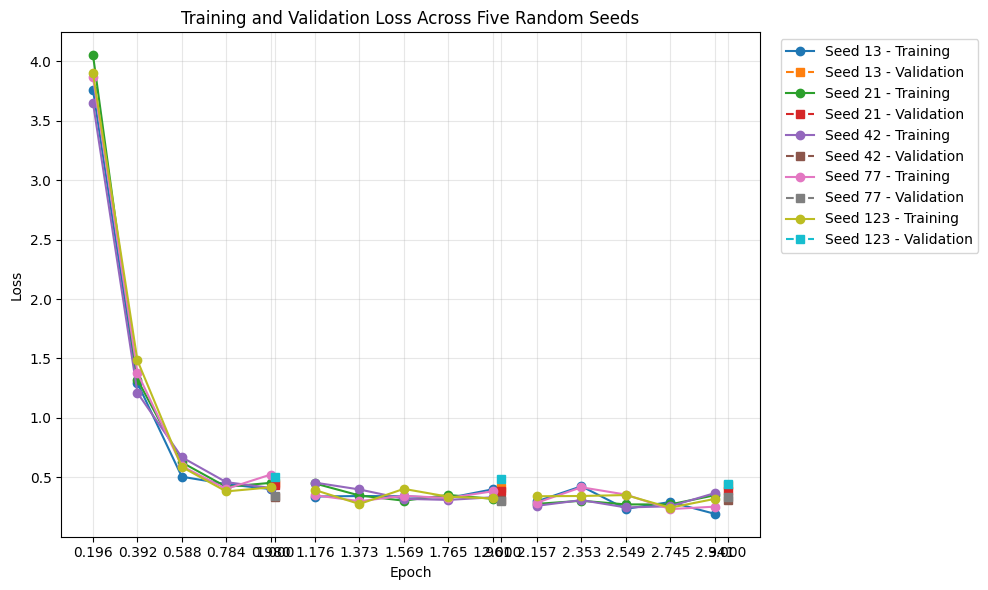


AVERAGE LOSS ACROSS FIVE SEEDS


,Epoch,Training Loss,Validation Loss
0,0.196078,3.844567,NaN
1,0.392157,1.337958,NaN
2,0.588235,0.596447,NaN
3,0.784314,0.421496,NaN
4,0.980392,0.441100,NaN
5,1.000000,NaN,0.412497
6,1.176471,0.396984,NaN
7,1.372549,0.332730,NaN
8,1.568627,0.342324,NaN
9,1.764706,0.330279,NaN


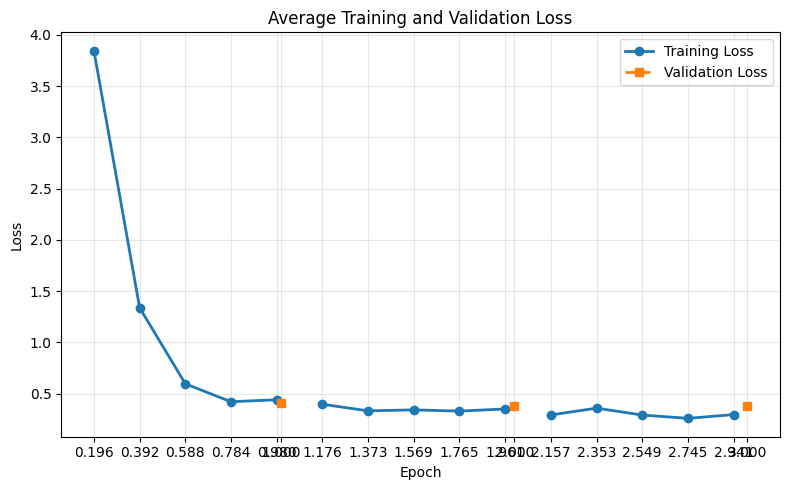




FINAL BERT-MEDIUM-AMHARIC RESULTS


,Seed,EM (%),F1 (%)
0,13,11.00,69.63
1,21,9.23,70.12
2,42,9.63,69.54
3,77,10.81,69.83
4,123,10.22,69.22



Mean ± Standard Deviation
EM: 10.18 ± 0.75%
F1: 69.67 ± 0.34%


In [ ]:
# ============================================================
# BERT-Medium-Amharic Medical QA
# Five Random Seeds
# EM, F1, Training Loss, Validation Loss
# ============================================================

import pandas as pd
import numpy as np
import torch
import random
import os
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    TrainingArguments,
    Trainer,
    default_data_collator
)

# ============================================================
# 1. Configuration
# ============================================================

MODEL_NAME = "rasyosef/bert-medium-amharic"

DATA_PATH = (
    "/content/drive/MyDrive/PHD folder/"
    "QA dataset/AmhMedQA.csv"
)

MAX_LENGTH = 384

# Five random seeds
SEEDS = [13, 21, 42, 77, 123]

# Training parameters
LEARNING_RATE = 3e-5
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 16
EPOCHS = 10
WEIGHT_DECAY = 0.01

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("================================================")
print("BERT-Medium-Amharic Medical QA")
print("Five Random Seeds")
print("================================================")

print("Model :", MODEL_NAME)
print("Device:", device)
print("Seeds :", SEEDS)


# ============================================================
# 2. Load Dataset
# ============================================================

df = pd.read_csv(DATA_PATH)

print("\nOriginal dataset shape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum())


# ============================================================
# 3. Clean Dataset
# ============================================================

df["context"] = (
    df["context"]
    .fillna("")
    .astype(str)
    .str.strip()
)

df["Question"] = (
    df["Question"]
    .fillna("")
    .astype(str)
    .str.strip()
)

df["Answer"] = (
    df["Answer"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# Remove empty samples
df = df[
    (df["context"].str.len() > 0) &
    (df["Question"].str.len() > 0) &
    (df["Answer"].str.len() > 0)
].copy()

df = df.reset_index(drop=True)

print("\nDataset after cleaning:")
print(df.shape)


# ============================================================
# 4. Verify Answer Exists in Context
# ============================================================

def find_answer_start(row):

    return row["context"].find(
        row["Answer"]
    )


df["answer_start"] = df.apply(
    find_answer_start,
    axis=1
)

valid_df = df[
    df["answer_start"] >= 0
].copy()

invalid_count = (
    len(df) - len(valid_df)
)

print("\nValid examples:", len(valid_df))
print("Invalid answer spans:", invalid_count)

df = valid_df.reset_index(drop=True)


# ============================================================
# 5. Convert to Hugging Face Dataset
# ============================================================

dataset = Dataset.from_pandas(
    df,
    preserve_index=False
)

print("\nHugging Face Dataset:")
print(dataset)


# ============================================================
# 6. Load Tokenizer
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("\nTokenizer loaded successfully.")


# ============================================================
# 7. Tokenization and Answer Alignment
# ============================================================

def preprocess_function(examples):

    questions = [
        q.strip()
        for q in examples["Question"]
    ]

    contexts = examples["context"]

    inputs = tokenizer(
        questions,
        contexts,
        max_length=MAX_LENGTH,
        truncation="only_second",
        padding="max_length",
        return_offsets_mapping=True
    )

    start_positions = []
    end_positions = []

    for i, offsets in enumerate(
        inputs["offset_mapping"]
    ):

        answer = examples["Answer"][i]
        context = examples["context"][i]
        start_char = context.find(answer)
        # Answer not found
        if start_char < 0:
            start_positions.append(0)
            end_positions.append(0)
            continue
        end_char = (
            start_char + len(answer)        )
        sequence_ids = inputs.sequence_ids(i)
        # ----------------------------------------------------
        # Find context start
        # ----------------------------------------------------

        context_start = 0

        while (
            context_start < len(sequence_ids)
            and sequence_ids[context_start] != 1
        ):
            context_start += 1

        # ----------------------------------------------------
        # Find context end
        # ----------------------------------------------------

        context_end = len(sequence_ids) - 1

        while (
            context_end >= 0
            and sequence_ids[context_end] != 1
        ):
            context_end -= 1

        # Invalid context span
        if (
            context_start >= len(sequence_ids)
            or context_end < context_start
        ):

            start_positions.append(0)
            end_positions.append(0)

            continue

        # ----------------------------------------------------
        # Find answer start token
        # ----------------------------------------------------

        token_start = context_start

        while (
            token_start <= context_end
            and offsets[token_start][0] <= start_char
        ):
            token_start += 1

        token_start -= 1

        # ----------------------------------------------------
        # Find answer end token
        # ----------------------------------------------------

        token_end = context_end

        while (
            token_end >= context_start
            and offsets[token_end][1] >= end_char
        ):
            token_end -= 1

        token_end += 1

        start_positions.append(
            token_start
        )

        end_positions.append(
            token_end
        )

    # Remove offset mapping
    inputs.pop("offset_mapping")

    inputs["start_positions"] = (
        start_positions
    )

    inputs["end_positions"] = (
        end_positions
    )

    return inputs


# ============================================================
# 8. Text Normalization
# ============================================================

def normalize(text):

    return str(text).strip()


# ============================================================
# 9. Exact Match
# ============================================================

def compute_em(
    prediction,
    truth
):

    return int(
        normalize(prediction)
        ==
        normalize(truth)
    )


# ============================================================
# 10. F1 Score
# ============================================================

def compute_f1(
    prediction,
    truth
):

    pred_tokens = (
        normalize(prediction)
        .split()
    )

    truth_tokens = (
        normalize(truth)
        .split()
    )

    if len(pred_tokens) == 0:
        return 0.0

    if len(truth_tokens) == 0:
        return 0.0

    common = (
        set(pred_tokens)
        &
        set(truth_tokens)
    )

    if len(common) == 0:
        return 0.0

    precision = (
        len(common)
        /
        len(pred_tokens)
    )

    recall = (
        len(common)
        /
        len(truth_tokens)
    )

    if precision + recall == 0:
        return 0.0

    f1 = (
        2
        * precision
        * recall
        /
        (precision + recall)
    )

    return f1


# ============================================================
# 11. Prediction Function
# ============================================================

def predict_answer(
    model,
    tokenizer,
    question,
    context
):

    inputs = tokenizer(
        question,
        context,
        return_tensors="pt",
        truncation="only_second",
        max_length=MAX_LENGTH,
        padding=True
    )

    # Move inputs to model device
    inputs = {
        key: value.to(model.device)
        for key, value in inputs.items()
    }

    model.eval()

    with torch.no_grad():

        outputs = model(
            **inputs
        )

    start_logits = (
        outputs.start_logits
    )

    end_logits = (
        outputs.end_logits
    )

    start = torch.argmax(
        start_logits,
        dim=1
    ).item()

    end = torch.argmax(
        end_logits,
        dim=1
    ).item()

    # Prevent invalid span
    if end < start:
        end = start
    answer_tokens = (
        inputs["input_ids"]
        [0][start:end + 1]    )
    answer = tokenizer.decode(
        answer_tokens,
        skip_special_tokens=True    )
    return answer
# ============================================================
# 12. Store All Results
# ============================================================
all_results = []
all_loss_history = []
# ============================================================
# 13. Five-Seed Experiment
# ============================================================
for SEED in SEEDS:
    print("\n\n")
    print("================================================")
    print(f"STARTING EXPERIMENT - SEED {SEED}")
    print("================================================")
    # --------------------------------------------------------
    # Set random seeds
    # --------------------------------------------------------

    random.seed(SEED)

    np.random.seed(SEED)

    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        torch.cuda.manual_seed_all(SEED)
   # --------------------------------------------------------
    # Train/Test Split
    # --------------------------------------------------------
    dataset_split = dataset.train_test_split(
        test_size=0.20,
        seed=SEED    )
    train_dataset = (
        dataset_split["train"]    )
    test_dataset = (
        dataset_split["test"]    )
    print(f"\nSeed {SEED} training samples:",len(train_dataset))

    print(
        f"Seed {SEED} testing samples:",
        len(test_dataset)
    )

    # --------------------------------------------------------
    # Tokenization
    # --------------------------------------------------------

    tokenized_train = train_dataset.map(
        preprocess_function,
        batched=True,
        remove_columns=train_dataset.column_names    )
    tokenized_test = test_dataset.map(
        preprocess_function,
        batched=True,
        remove_columns=test_dataset.column_names    )
    # --------------------------------------------------------
    # Load fresh model
    # --------------------------------------------------------
    model = (AutoModelForQuestionAnswering.from_pretrained(MODEL_NAME) )
    model.to(device)
    # --------------------------------------------------------
    # Training output directory
    # --------------------------------------------------------
    output_dir = (
        f"./bert_medium_amharic_seed_{SEED}"
    )
    # --------------------------------------------------------
    # Training Arguments
    # --------------------------------------------------------

    training_args = TrainingArguments(

        output_dir=output_dir,

        eval_strategy="epoch",

        save_strategy="epoch",
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=EPOCHS,
        weight_decay=WEIGHT_DECAY,
        logging_steps=50,
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=SEED,
        data_seed=SEED
    )

    # --------------------------------------------------------
    # Trainer
    # --------------------------------------------------------

    trainer = Trainer(

        model=model,

        args=training_args,

        train_dataset=tokenized_train,

        eval_dataset=tokenized_test,

        data_collator=default_data_collator
    )

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    print(
        f"\nTraining BERT-Medium-Amharic "
        f"with seed {SEED}..."
    )

    trainer.train()

    # ========================================================
    # 14. Extract Training and Validation Loss
    # ========================================================

    log_history = trainer.state.log_history

    train_loss_history = []
    eval_loss_history = []

    for log in log_history:

        if (
            "loss" in log
            and "epoch" in log
        ):

            train_loss_history.append({
                "Seed": SEED,
                "Epoch": log["epoch"],
                "Training Loss": log["loss"]
            })

        if (
            "eval_loss" in log
            and "epoch" in log
        ):

            eval_loss_history.append({
                "Seed": SEED,
                "Epoch": log["epoch"],
                "Validation Loss": log["eval_loss"]
            })

    # --------------------------------------------------------
    # Convert to DataFrames
    # --------------------------------------------------------

    train_loss_df = pd.DataFrame(
        train_loss_history
    )

    eval_loss_df = pd.DataFrame(
        eval_loss_history
    )

    # --------------------------------------------------------
    # Average training loss per epoch
    # --------------------------------------------------------

    if not train_loss_df.empty:

        train_epoch_loss = (
            train_loss_df
            .groupby("Epoch")["Training Loss"]
            .mean()
            .reset_index()
        )

    else:

        train_epoch_loss = pd.DataFrame(
            columns=[
                "Epoch",
                "Training Loss"
            ]
        )

    # --------------------------------------------------------
    # Validation loss
    # --------------------------------------------------------

    if not eval_loss_df.empty:

        eval_epoch_loss = (
            eval_loss_df[
                ["Epoch", "Validation Loss"]
            ]
            .groupby("Epoch")
            .mean()
            .reset_index()
        )

    else:

        eval_epoch_loss = pd.DataFrame(
            columns=[
                "Epoch",
                "Validation Loss"
            ]
        )

    # --------------------------------------------------------
    # Merge loss table
    # --------------------------------------------------------

    loss_table = pd.merge(
        train_epoch_loss,
        eval_epoch_loss,
        on="Epoch",
        how="outer"
    )

    loss_table.insert(
        0,
        "Seed",
        SEED
    )

    loss_table = loss_table.sort_values(
        "Epoch"
    )

    print("\n--------------------------------------------")
    print(f"LOSS HISTORY - SEED {SEED}")
    print("--------------------------------------------")

    display(loss_table)

    # --------------------------------------------------------
    # Save loss history
    # --------------------------------------------------------

    loss_table.to_csv(
        f"{output_dir}/loss_history_seed_{SEED}.csv",
        index=False
    )

    # Add to global history
    all_loss_history.append(
        loss_table
    )

    # ========================================================
    # 15. Evaluation
    # ========================================================

    EM = []
    F1 = []

    print(
        f"\nEvaluating seed {SEED}..."
    )

    for example in test_dataset:

        question = (
            example["Question"]
        )

        context = (
            example["context"]
        )

        truth = (
            example["Answer"]
        )

        prediction = predict_answer(
            model,
            tokenizer,
            question,
            context
        )

        em = compute_em(
            prediction,
            truth
        )

        f1 = compute_f1(
            prediction,
            truth
        )

        EM.append(em)

        F1.append(f1)

    # --------------------------------------------------------
    # Calculate EM and F1
    # --------------------------------------------------------

    EM_score = (
        np.mean(EM) * 100
    )

    F1_score = (
        np.mean(F1) * 100
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    all_results.append({

        "Seed": SEED,

        "EM (%)": round(
            EM_score,
            2
        ),

        "F1 (%)": round(
            F1_score,
            2
        )
    })

    # --------------------------------------------------------
    # Display current seed results
    # --------------------------------------------------------

    print("\n--------------------------------------------")
    print(f"RESULTS FOR SEED {SEED}")
    print("--------------------------------------------")

    print(
        f"EM : {EM_score:.2f}%"
    )

    print(
        f"F1 : {F1_score:.2f}%"
    )

    # --------------------------------------------------------
    # Free GPU memory
    # --------------------------------------------------------

    del model

    del trainer

    if torch.cuda.is_available():

        torch.cuda.empty_cache()


# ============================================================
# 16. Five-Seed EM/F1 Results
# ============================================================

results_df = pd.DataFrame(
    all_results
)

print("\n\n")
print("================================================")
print("RESULTS FOR ALL FIVE RANDOM SEEDS")
print("================================================")

display(results_df)


# ============================================================
# 17. Mean and Standard Deviation
# ============================================================

mean_em = (
    results_df["EM (%)"]
    .mean()
)

std_em = (
    results_df["EM (%)"]
    .std()
)

mean_f1 = (
    results_df["F1 (%)"]
    .mean()
)

std_f1 = (
    results_df["F1 (%)"]
    .std()
)


print("\n================================================")
print("OVERALL FIVE-SEED RESULTS")
print("================================================")

print(
    f"EM Mean ± Std: "
    f"{mean_em:.2f} ± {std_em:.2f}"
)

print(
    f"F1 Mean ± Std: "
    f"{mean_f1:.2f} ± {std_f1:.2f}"
)


# ============================================================
# 18. Publication-Ready EM/F1 Summary Table
# ============================================================

summary_table = pd.DataFrame({

    "Model": [
        "BERT-Medium-Amharic"
    ],

    "EM Mean (%)": [
        round(mean_em, 2)
    ],

    "EM Std (%)": [
        round(std_em, 2)
    ],

    "F1 Mean (%)": [
        round(mean_f1, 2)
    ],

    "F1 Std (%)": [
        round(std_f1, 2)
    ]

})

print("\n================================================")
print("PUBLICATION SUMMARY")
print("================================================")

display(summary_table)


# ============================================================
# 19. Combine All Loss Tables
# ============================================================

all_loss_df = pd.concat(
    all_loss_history,
    ignore_index=True
)

print("\n================================================")
print("TRAINING AND VALIDATION LOSS TABLE")
print("================================================")

display(all_loss_df)


# ============================================================
# 20. Save Complete Loss Table
# ============================================================

all_loss_df.to_csv(
    "bert_medium_amharic_five_seed_loss_history.csv",
    index=False
)

results_df.to_csv(
    "bert_medium_amharic_five_seed_results.csv",
    index=False
)

summary_table.to_csv(
    "bert_medium_amharic_summary.csv",
    index=False
)


# ============================================================
# 21. Plot Training and Validation Loss
# ============================================================

plt.figure(
    figsize=(10, 6)
)

for seed in SEEDS:

    seed_data = all_loss_df[
        all_loss_df["Seed"] == seed
    ].sort_values("Epoch")

    if not seed_data.empty:

        plt.plot(
            seed_data["Epoch"],
            seed_data["Training Loss"],
            marker="o",
            label=f"Seed {seed} - Training"
        )

        plt.plot(
            seed_data["Epoch"],
            seed_data["Validation Loss"],
            marker="s",
            linestyle="--",
            label=f"Seed {seed} - Validation"
        )


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Training and Validation Loss Across Five Random Seeds"
)

plt.xticks(
    sorted(
        all_loss_df["Epoch"]
        .dropna()
        .unique()
    )
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()


# ============================================================
# 22. Average Training and Validation Loss Across Seeds
# ============================================================

average_loss = (
    all_loss_df
    .groupby("Epoch")[
        [
            "Training Loss",
            "Validation Loss"
        ]
    ]
    .mean()
    .reset_index()
)

print("\n================================================")
print("AVERAGE LOSS ACROSS FIVE SEEDS")
print("================================================")

display(average_loss)


# ============================================================
# 23. Plot Average Loss
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    average_loss["Epoch"],
    average_loss["Training Loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    average_loss["Epoch"],
    average_loss["Validation Loss"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Average Training and Validation Loss"
)

plt.xticks(
    sorted(
        average_loss["Epoch"]
    )
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 24. Final Results
# ============================================================

print("\n\n")
print("================================================")
print("FINAL BERT-MEDIUM-AMHARIC RESULTS")
print("================================================")

display(results_df)

print("\nMean ± Standard Deviation")

print(
    f"EM: {mean_em:.2f} ± {std_em:.2f}%"
)

print(
    f"F1: {mean_f1:.2f} ± {std_f1:.2f}%"
)

In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=loss_table)